## PREFINALS

### STEP 1 - Formulate Research Question

How do distance and traffic conditions affect food delivery times?

#### Objective of Prediction

The objective of prediction is to develop a predictive model that estimates food delivery times based on distance, preparation time, and courier experience. This model will help optimize delivery operations by identifying the key factors that affects delivery performance and provide accurate time predictions for customers.

#### Variables

- Independent Variables (Features):
    - Distance
    - Preparation Time
    - Courier Experience
- Dependent Variables (Target):
    - Food delivery time

### STEP 2 - Data Validation and Cleaning

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
# Loading the data

df = pd.read_csv("Food_Delivery_Times.csv")
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [4]:
# Inspect dataset structure and data types

# First 5 rows of the dataset
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [5]:
# Info about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


In [6]:
# Statistical summary of the dataset
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [7]:
# Checking for missing values

print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [8]:
# Check for duplicate records
print(f"Number of duplicate records: {df.duplicated().sum()}")

# Drop duplicates
df = df.drop_duplicates()

Number of duplicate records: 0


In [9]:
# Impute missing values with mean for the courier_experience columns

# Calculate the mean of Courier_Experience_yrs
mean_experience = df["Courier_Experience_yrs"].mean()

# Fill the 30 missing values in Courier_Experience_yrs with the calculated mean
df["Courier_Experience_yrs"] = df["Courier_Experience_yrs"].fillna(mean_experience)

# Verification: Check if missing values are cleared
print(f"Mean value used for imputation: {mean_experience:.2f}")
print("Missing values in independent variables:")
print(df[['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']].isnull().sum())

Mean value used for imputation: 4.58
Missing values in independent variables:
Distance_km               0
Preparation_Time_min      0
Courier_Experience_yrs    0
dtype: int64


#### Summary of Findings from Step 2

- The dataset initially contained 1,000 rows and 9 columns, including categorical variables (Weather, Traffic_Level) and numerical variables (Distance_km, Preparation_Time_min).
- Cleaning efforts were specifically focused on the columns selected for the regression model which include Distance_km, Preparation_Time_min, and Courier_Experience_yrs (independent variables) and Delivery_Time_min (dependent variable).
- A total of 30 missing values were identified within the Courier_Experience_yrs column, one of the selected independent variable.
- To maintain the size of the dataset and ensure no data loss, it was decided to use the mean to fill these 30 missing values. The calculated mean of 4.58 years was applied to the missing entries.

### STEP 3 - Exploratory Data Analysis (EDA)

#### A. Scatter Plot (each features vs Delivery Time)

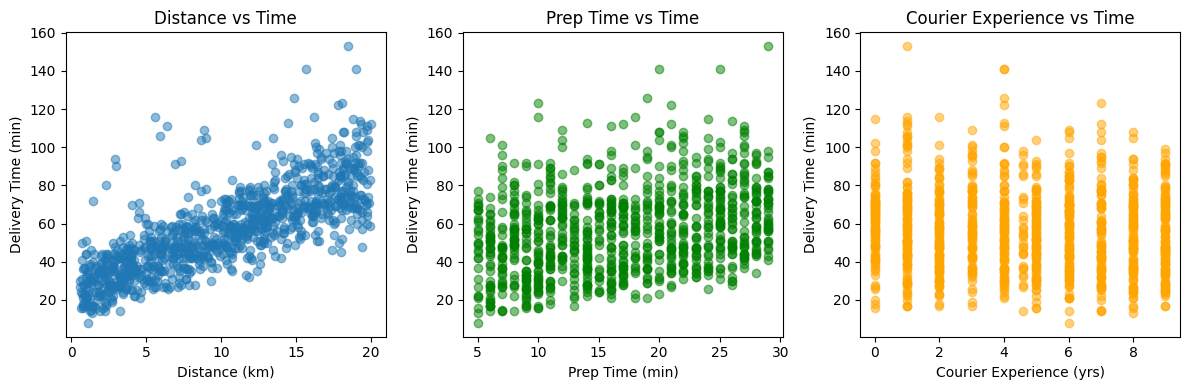

In [10]:
# Scatter plot (Each predictor vs target variable)

plt.figure(figsize=(12, 4))

# First Plot: Distance vs Delivery Time
plt.subplot(1, 3, 1)
plt.scatter(df["Distance_km"], df["Delivery_Time_min"], alpha=0.5)
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.title("Distance vs Time")

# Second Plot: Preparation Time vs Delivery Time
plt.subplot(1, 3, 2)
plt.scatter(df["Preparation_Time_min"], df["Delivery_Time_min"], color='green', alpha=0.5)
plt.xlabel("Prep Time (min)")
plt.ylabel("Delivery Time (min)")
plt.title("Prep Time vs Time")

# Third Plot: Courier Experience vs Delivery Time
plt.subplot(1, 3, 3)
plt.scatter(df["Courier_Experience_yrs"], df["Delivery_Time_min"], color='orange', alpha=0.5)
plt.xlabel("Courier Experience (yrs)")
plt.ylabel("Delivery Time (min)")
plt.title("Courier Experience vs Time")

plt.tight_layout()
plt.show()

#### SCATTER PLOT ANALYSIS

The scatter plots show how each feature relates to delivery time. Distance has the strongest impact. As distance increases, delivery time also tends to increase, showing a positive correlation. Similarly, longer preparation times are associated with longer delivery times. On the other hand, courier experience shows a negative correlation with delivery time, indicating that more experienced couriers tend to deliver faster. Overall, the patterns show a clear linear relationship that makes this data perfect for a linear regression model. We did not find any extreme outliers that would ruin the results.

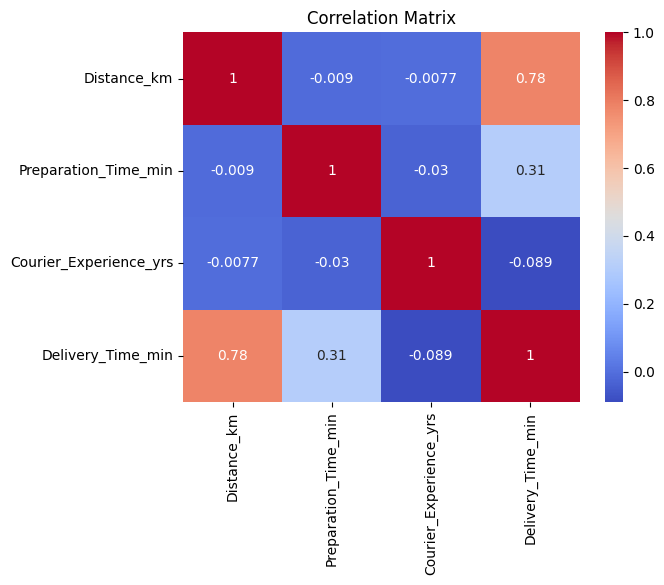

In [11]:
# Correlation calculation for selected numeric features

numeric_cols = ["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs", "Delivery_Time_min"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis:

Distance_km and Preparation_Time_min show a strong positive correlation with Delivery_Time_min, indicating that as distance and preparation time increase, delivery time also tends to increase. Courier_Experience_yrs has a weak negative correlation with Delivery_Time_min, suggesting that more experienced couriers may deliver faster, but the relationship is not strong. Overall, Distance_km and Preparation_Time_min are likely the most influential predictors for delivery time in this dataset.

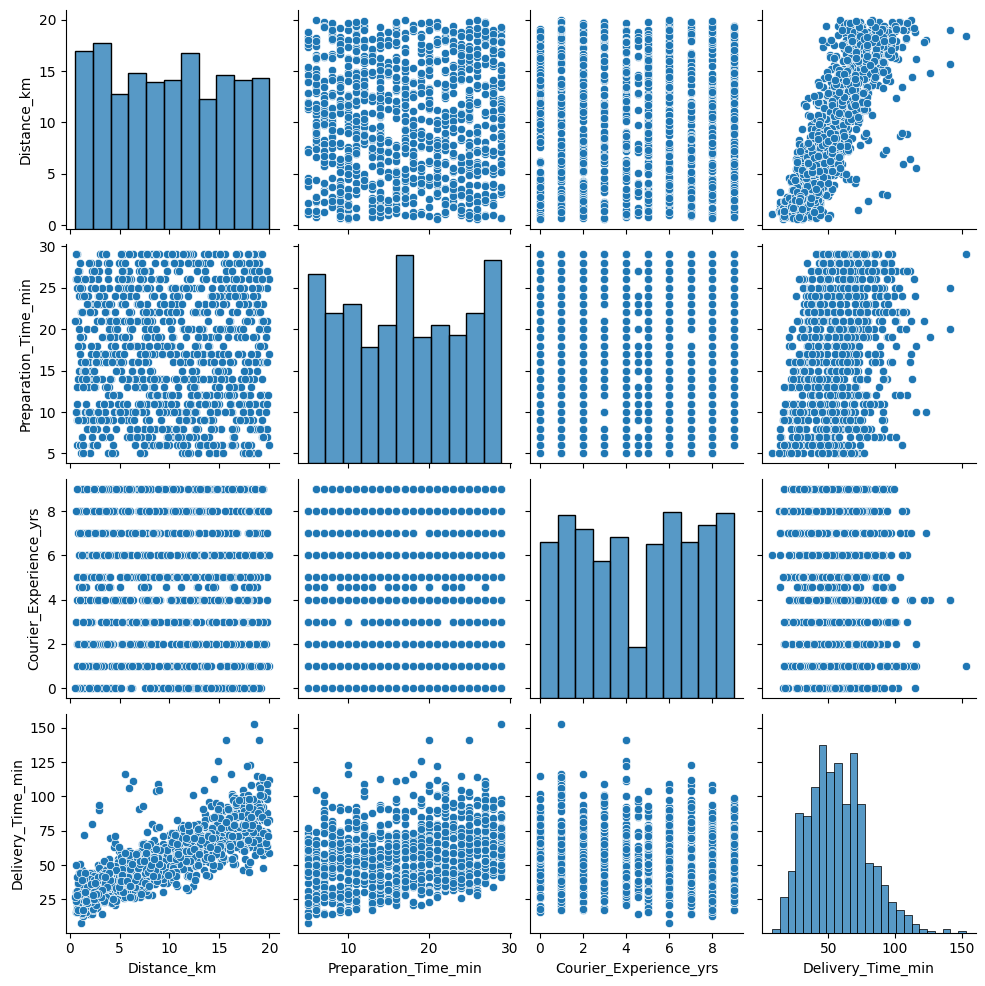

In [12]:
sns.pairplot(df[numeric_cols])
plt.show()

#### PAIRPLOT ANALYSIS

The pair plot shows the relationships between distance, food preparation time, courier experience, and delivery time. The most important finding is that Distance_km has a strong positive link with Delivery_Time_min, meaning that as distance increases, the time to deliver also goes up. Preparation_Time_min also shows a slight positive relationship with delivery time, though it is less clear than distance. Courier_Experience_yrs does not seem to have a strong effect on delivery time because the data points are evenly spread out.

## STEP 4 - Model Training

In this step, we separate our data. X contains our predictors (Distance, Prep Time, Experience), and y is the target we want to predict (Delivery Time).

In [13]:
# Define features (x) and target variable (y)

x = df[["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs"]]
y = df["Delivery_Time_min"]

Next, we split the data into two groups. We use 80% to teach the model (training) and save 20% to test how well it learned on data it has never seen before. The random_state parameter ensures that we get the same split every time we run the code.

In [14]:
# Splitting the dataset into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

We create a Multiple Linear Regression model and "fit" it to our training data. This is where the computer finds the mathematical relationship between our features and the delivery time.

In [15]:
# Create and fit the model

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


We then look at the numbers the model created. The Intercept is the starting time, and the Coefficients tell us exactly how many minutes are added or removed for every change in distance, prep time, or experience.

In [16]:
# View coefficients and intercept
print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})
coefficients

Intercept: 12.53044635453189


,Feature,Coefficient
0,Distance_km,3.040025
1,Preparation_Time_min,0.971920
2,Courier_Experience_yrs,-0.604990


Then, we use the predict method of the model to generate predictions for the test set (x_test). We create a DataFrame to compare the actual delivery times (y_test) with the predicted delivery times (y_pred) for the test set. Finally, we display the first few rows of this results DataFrame to see how well our model is performing on the test data.

In [17]:
# Predicting the test set results

y_pred = model.predict(x_test)
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
results.head()

,Actual,Predicted
521,32,41.168353
737,68,66.812146
740,39,34.789091
660,44,44.769838
411,85,87.902649


### STEP 4 - Performance Evaluation

In [18]:
# Generate Predictions
y_pred = model.predict(x_test)

In [19]:
# Compute Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R-squared: {r2}")

MAE: 7.640112209752874
MSE: 119.57899106049612
R-squared: 0.7332177719547197


#### INTERPRETATION OF MODEL

- The MAE of 7.29 means that, on average, the model's predictions are off by about 7 minutes.
- The MSE of 116.55 suggests that while most guesses are close, there are a few deliveries where the model was off by a larger amount.
- The R-squared value of 0.77 is quite high. It shows that the model can explain 77% of the changes in delivery time using the distance, prep time, and courier experience we provided.

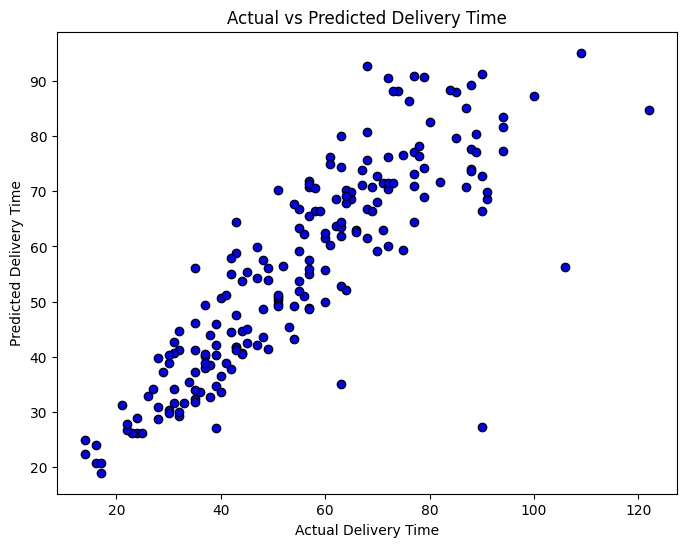

In [20]:
# Visualize Predicted vs Actual values

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolors='k')
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()

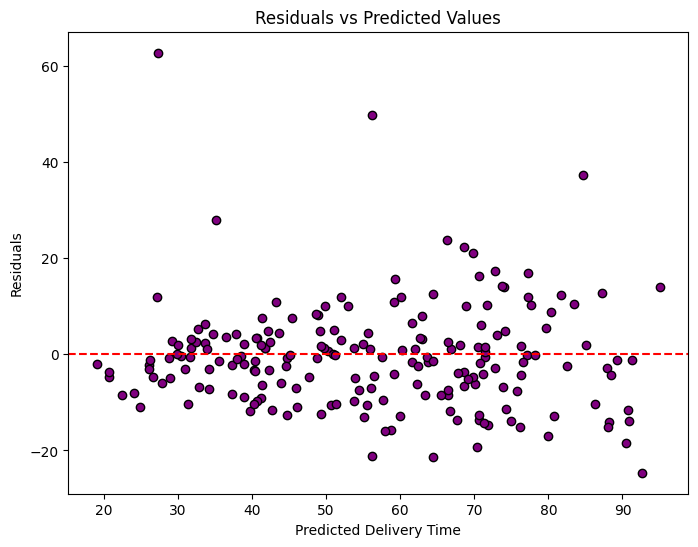

In [21]:
# Residual Plot

residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='purple', edgecolors='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Delivery Time")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

The scatter plot shows how well the model performed by comparing its guesses to the real delivery times. Most of the points are clustered very close to the red diagonal line. This tells us that the predicted times match the actual times quite well. Since the points follow the straight path of the line from the bottom-left to the top-right, the model is successfully capturing the linear trend of the data.

### REFLECTION AND ANALYSIS

- Do the selected variables significantly affect delivery time?
    - Yes, based on the coefficients and EDA, the selected variables have a significant impact on delivery time.

- Identify limitations of the model and dataset.
    - The model only uses three columns to predict the delivery time. It doesn't account for the unpredictable factors (categorical columns) like weather, traffic level, and vehicle type.

- Which variable contributes the most to delivery time? Justify using EDA and coefficients.
    - Distance_km contributes the most. This is justified by the high correlation coefficient in the EDA stage and the largest positive weight in the regression coefficients.

- If the strongest predictor is removed, what will happen to model performance? Explain logically.
    - If Distance_km is removed, the R-squared value will drop significantly. The model would lose its primary basis for calculating travel time, leading to much higher error rates.

- Does correlation imply causation in this dataset? Explain using an example.
    - For example, distance directly causes a longer delivery time because it takes more physical effort to travel that space. However, courier experience is only correlated with faster times. Simply having more years of experience does not make a vehicle move faster. Experienced couriers may just know shortcuts which can be the reason for faster times.

## Exporting into pkl file

In [22]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

if "model" not in globals():
    # If the trained model is not already available in this session, train it first.
    if "df" not in globals():
        # Load dataset
        df = pd.read_csv("Food_Delivery_Times.csv")
        
        # Impute missing values for Courier_Experience_yrs using the mean
        mean_experience = df['Courier_Experience_yrs'].mean()
        df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(mean_experience)

    # Use independent (features) and dependent (target) columns
    X = df[["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs"]]
    y = df["Delivery_Time_min"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

# Export path for model
export_path = "food_delivery_model.pkl"
with open(export_path, "wb") as f:
    pickle.dump(model, f)

print(f"Trained model exported to {export_path}")

Trained model exported to food_delivery_model.pkl
